# Zufallszahlen Erzeugen

## Vertiefung

### Übersicht

1. Kontinuierliche Gleichverteilung mit Middle-Square-Methode
3. NumPy Random
4. Inversionsmethode (Inverse Transform Sampling)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### 1. Kontinuierliche Gleichverteilung mit Middle-Square-Methode

#### a) Grössere Anzahl Stellen

In der Einarbeitung haben wir die Middle-Square-Methode mit 4-stelligen Zahlen kennengelernt. Diese Methode lässt sich auch auf eine beliebige Anzahl Stellen verallgemeinern. Es muss aber eine gerade Anzahl sein.

Generell gilt: Je mehr Stellen die Zahlen haben, desto grösser kann die maximale Periode der Methode sein.

Wir implementieren die MSM mal für 16-stellige Zahlen.

In [2]:
def msm_next_4(number):
    """Ein Schritt der Middle-Square-Method für 4-stellige Zahlen. (Aus der Einarbeitung)"""
    n2_padded = str(number**2).zfill(8)
    return int(n2_padded[2:-2])


def msm_next_16(number):
    """Ein Schritt der Middle-Square-Method für 16-stellige Zahlen."""
    n2_padded = str(number**2).zfill(32)
    return int(n2_padded[8:-8])


msm_next_16(3451234683710473)

8420461286073748

In [3]:
def msm_16(seed, n):
    """Middle-Square-Method mit 16-stelligen Zahlen mit Seed und Anzahl Schritten n"""
    assert len(str(seed)) == 16, "Seed muss 16-stellig sein."
    number = seed
    sequence = []
    for _ in range(n):
        number = msm_next_16(number)
        sequence.append(number)
    return np.array(sequence)

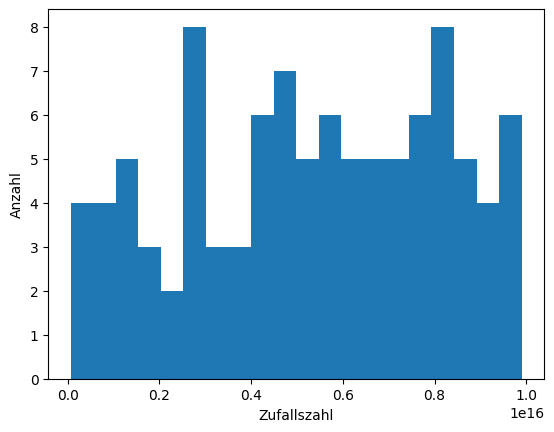

In [4]:
x = msm_16(3451234683710473, 100)

plt.hist(x, bins=20)
plt.xlabel("Zufallszahl")
plt.ylabel("Anzahl")
plt.show()

#### b) Mapping auf das Einheitsintervall

Der MSM Algorithmus (wie bessere Algorithmen auch) erzeugt ganzzahlige Zufallszahlen, die Gleichverteilt sind. Diese müssen für viele Anwendungen zuerst auf das reelle Einheitsintervall von 0 bis 1 abgebildet werden. Je nach Konvention wird das Intervall entweder inklusive oder exklusive der Grenzen betrachtet. Wir folgen hier der Konvention von NumPy und nehmen das halb-offene Intervall $[0,1)$, siehe [`numpy.random.Generator.uniform`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.uniform.html).

$$
    X \sim U(0,1)
    \quad \Rightarrow \quad
    f(x) = \begin{cases}
        1 & \text{für } x \in [0,1) \\
        0 & \text{sonst}
    \end{cases}
$$

Hier steht $U(0,1)$ für die Gleichverteilung auf dem Intervall $[0,1)$ und $f(x)$ für die Wahrscheinlichkeitsdichte.

Die MSM-Methode erzeugt natürliche Zahlen $0 \leq z < 10^m$, wobei $m$ die Anzahl Stellen des Seeds ist. Durch division mit $10^n$ erhalten wir reelle Zufallszahlen im Intervall $[0,1)$:

$$
    x = \frac{z}{10^m}
$$


In [5]:
def uniform(seed, n):
    numbers = msm_16(seed, n)
    upper_bound = 10 ** len(str(seed))
    return numbers / upper_bound

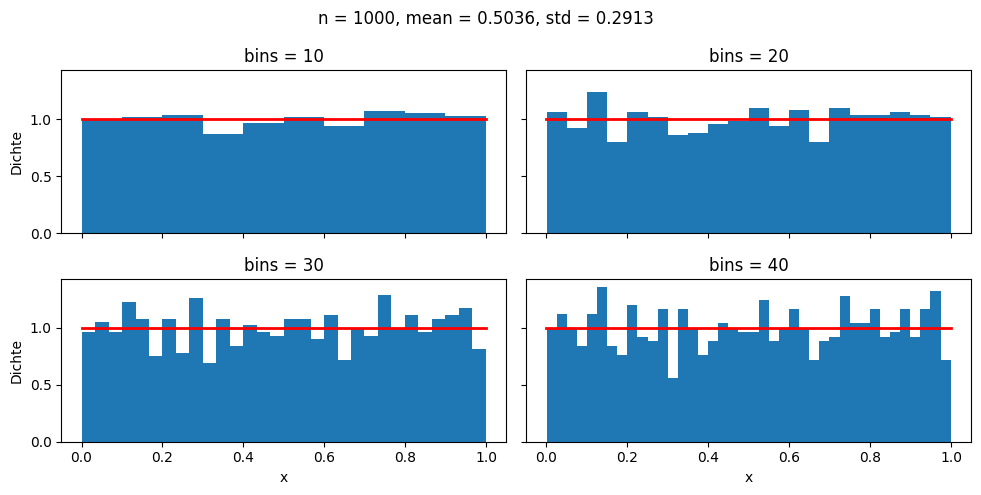

In [6]:
u = uniform(3451234683710473, 1000)

fig, axes = plt.subplots(2, 2, figsize=(10, 5), sharex=True, sharey=True)
for ax, bins in zip(axes.flat, (10, 20, 30, 40)):
    ax.hist(u, bins=bins, density=True)
    ax.plot([0, 1], [1, 1], color="red", linewidth=2)
    ax.set_title(f"bins = {bins}")

for ax in axes[-1, :]:
    ax.set_xlabel("x")
for ax in axes[:, 0]:
    ax.set_ylabel("Dichte")


plt.suptitle(f"n = {len(u)}, mean = {u.mean():.4f}, std = {u.std():.4f}")
plt.tight_layout()
plt.show()

### 2. NumPy Random

Der Einstiegspunkt in die Dokumentation ist hier: https://numpy.org/doc/stable/reference/random/index.html

Grundsätzlich wird zuerst ein [Random Generator](https://numpy.org/doc/stable/reference/random/generator.html) mit einem Seed instanziert und dann für die Erzeugung von Pseudozufallszahlen verwendet

#### a) Gleichverteilung

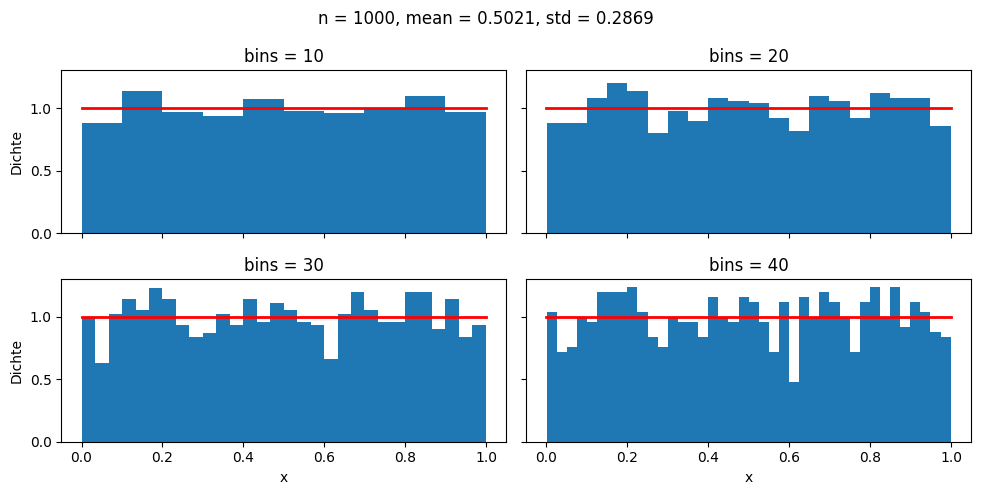

In [7]:
rng = np.random.default_rng(3451234683710473)
u = rng.uniform(0, 1, 1000)

fig, axes = plt.subplots(2, 2, figsize=(10, 5), sharex=True, sharey=True)
for ax, bins in zip(axes.flat, (10, 20, 30, 40)):
    ax.hist(u, bins=bins, density=True)
    ax.plot([0, 1], [1, 1], color="red", linewidth=2)
    ax.set_title(f"bins = {bins}")

for ax in axes[-1, :]:
    ax.set_xlabel("x")
for ax in axes[:, 0]:
    ax.set_ylabel("Dichte")

plt.suptitle(f"n = {len(u)}, mean = {u.mean():.4f}, std = {u.std():.4f}")
plt.tight_layout()
plt.show()

#### b) Weitere Verteilungen

Der NumPy Random Generator bietet eine grosse [Auswahl Verteilungen](https://numpy.org/doc/stable/reference/random/generator.html#distributions) an. Scipy bietet noch [weitere Verteilungen](https://docs.scipy.org/doc/scipy/reference/stats.html) an, unter anderem auch [multivariate Verteilungen](https://docs.scipy.org/doc/scipy/reference/stats.html#multivariate-distributions).

Beispiel: [Gammaverteilung](https://de.wikipedia.org/wiki/Gammaverteilung) mit [`rng.gamma`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.gamma.html)

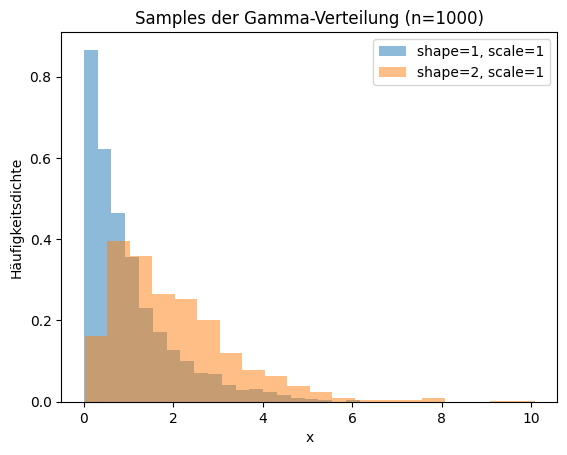

In [8]:
rng = np.random.default_rng()

n = 1000
g1 = rng.gamma(1, 1, n)
g2 = rng.gamma(2, 1, n)

plt.hist(g1, bins=20, density=True, alpha=0.5, label="shape=1, scale=1")
plt.hist(g2, bins=20, density=True, alpha=0.5, label="shape=2, scale=1")

plt.legend()
plt.xlabel("x")
plt.ylabel("Häufigkeitsdichte")
plt.title(f"Samples der Gamma-Verteilung (n={n})")
plt.show()

#### c) Samples aus Arrays ziehen


Samples aus einem Array zieht man mit [`rng.choice`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.choice.html) entweder mit oder ohne zurücklegen `replace=True/False`.

Mit Zurücklegen (default):

In [9]:
rng = np.random.default_rng()
x = np.arange(8)

print("Mit Zurücklegen:", rng.choice(x, size=20))

print("Ohne Zurücklegen:", rng.choice(x, size=4, replace=False))

Mit Zurücklegen: [0 1 7 5 5 1 4 2 5 1 7 5 6 2 7 4 4 0 0 5]
Ohne Zurücklegen: [7 4 5 6]


Zusätzlich kann man mit der Option `p=...` die Wahrscheinlichkeiten der Elemente angeben. (Die Summe der Wahrscheinlichkeiten muss 1 ergeben.)

In [10]:
x = np.arange(3)
p = [0.1, 0.6, 0.3]

y = rng.choice(x, 1000, p=p)

from collections import Counter

counter = Counter(y)

np.array([counter[xi] for xi in x]) / len(y)

array([0.1  , 0.616, 0.284])

#### d) Arrays Mischen


Zum Mischen von Arrays gibt es 3 Funktionen:

- [`rng.shuffle`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.shuffle.html)	
- [`rng.permutation`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.permutation.html)
- [`rng.permuted`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.permuted.html)

Vorsicht: [Dokumentation](https://numpy.org/doc/stable/reference/random/generator.html#permutations) genau lesen.

- `rng.shuffle` verändert das Array inplace (Mutation!), `rng.permuted` und `rng.permutation` geben ein neues Array zurück.
- `rng.shuffle` und `rng.permutation` mischen das Array entlang einer Achse (default `axis=0`). Das heisst, es werden nur Zeilen (bzw. Spalten) vertauscht aber nicht die Elemente innerhalb einer Zeile (bzw. Spalte).
- `rng.permuted` mischt das ganze Array.

In [11]:
rng = np.random.default_rng(42)
x = np.arange(8).reshape(4, 2)

print("x before\n", x)
print("shuffle\n", rng.shuffle(x))
print("x after\n", x)

x before
 [[0 1]
 [2 3]
 [4 5]
 [6 7]]
shuffle
 None
x after
 [[6 7]
 [4 5]
 [2 3]
 [0 1]]


In [12]:
rng = np.random.default_rng(42)
x = np.arange(8).reshape(4, 2)

print("x before\n", x)
print("permutation\n", rng.permutation(x))
print("x after\n", x)

x before
 [[0 1]
 [2 3]
 [4 5]
 [6 7]]
permutation
 [[6 7]
 [4 5]
 [2 3]
 [0 1]]
x after
 [[0 1]
 [2 3]
 [4 5]
 [6 7]]


In [13]:
rng = np.random.default_rng(42)
x = np.arange(8).reshape(4, 2)

print("x before\n", x)
print("permuted\n", rng.permuted(x))
print("x after\n", x)

x before
 [[0 1]
 [2 3]
 [4 5]
 [6 7]]
permuted
 [[3 4]
 [2 7]
 [6 1]
 [5 0]]
x after
 [[0 1]
 [2 3]
 [4 5]
 [6 7]]


### 3. Inversionsmethode (Inverse Transform Sampling)

Wie werden nun Verteilungen erzeugt, die nicht Gleichverteilungen sind? Die einfachsten Verfahren sind:

- [Inversionsmethode](https://de.wikipedia.org/wiki/Inversionsmethode)
- [Verwerfungsmethode](https://de.wikipedia.org/wiki/Verwerfungsmethode)

Hier diskutieren und implementieren wir die Inversionsmethode für [diskrete Verteilungen](https://de.wikipedia.org/wiki/Diskrete_Wahrscheinlichkeitsverteilung). Die Inversionsmethode für [stetige Verteilungen](https://de.wikipedia.org/wiki/Stetige_Wahrscheinlichkeitsverteilung) wird im Übungsblatt implementiert und kam bereits im Modul "Statistik & Wahrscheinlichkeit" vor (Serie 3, Aufgabe 3c).


#### a) Beispiel: Ampel-Farben

Als Beispiel schauen wir an, welche Farbe wohl eine Verkehrsampel anzeigt, wenn man bei ihr ankommt. Wenn die Ampel immer 10 Sekunden auf grün steht, 20 Sekunden auf rot und dazwischen je 1 Sekunden auf Orange, dann ist die Wahrscheinlichkeit folgendermassen

$$
\begin{align*}
    P(\text{grün}) &= \frac{10}{32} \,,\qquad&
    P(\text{rot}) &= \frac{20}{32} \,,\qquad&
    P(\text{orange}) &= \frac{2}{32}
\end{align*}
$$

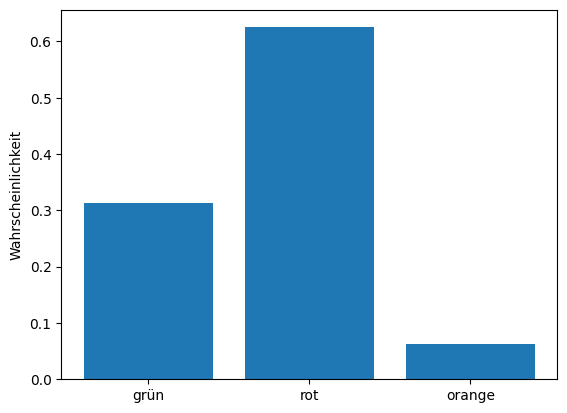

In [14]:
x = np.array(["grün", "rot", "orange"])
p = np.array([10, 20, 2])
p = p / p.sum()

plt.bar(x, p)
plt.ylabel("Wahrscheinlichkeit")
plt.show()

Das Ziel ist nun, Realisierungen der Zufallsvariable mit Wahrscheinlichkeit $P(k)$ und $k\in\{\text{grün}, \text{rot}, \text{orange}\}$ zu erzeugen.


#### b) Implementation der Inversionsmethode

**Erster Schritt**: Grün oder nicht grün?

Ist eine gleichverteilte Zufallszahl $u\sim U(0,1)$ kleiner oder gleich $P(\text{grün})$, dann ist die Ampel grün, sonst nicht.

In [15]:
rng = np.random.default_rng()

In [16]:
u = rng.uniform()

if u < p[0]:
    print(f"u={u} -> grün")
else:
    print(f"u={u} -> nicht grün")

u=0.06930910570835769 -> grün


**Zweiter Schritt**: Wie bestimmt man, welches Licht an ist, wenn nicht das grüne?

Dazu schauen wir die kumulative Verteilungsfunktion (CDF) an.

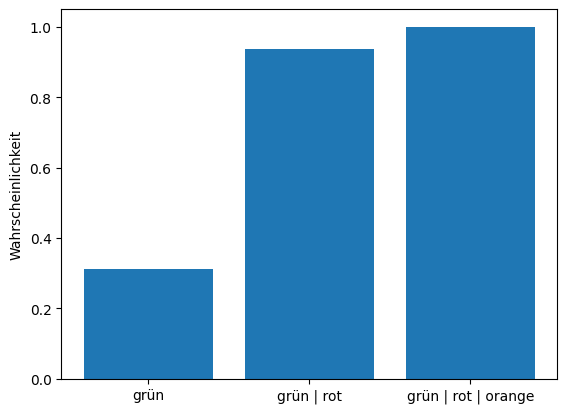

In [17]:
# Kumulative Verteilungsfunktion
# p = [10,    20,       2] / 32
# cdf = [10, 10+20, 10+20+2] / 32

cdf = np.cumsum(p)
xx = ["grün", "grün | rot", "grün | rot | orange"]

plt.bar(xx, cdf)
plt.ylabel("Wahrscheinlichkeit")
plt.show()

Nun können wir auf die CDF würfeln und erhalten eine Realisierung der Zufallsvariable.

In [18]:
u = rng.uniform(0, 1)
i = np.searchsorted(cdf, u)

print(cdf)
print(f"{u} -> {i} -> {x[i]}")

[0.3125 0.9375 1.    ]
0.19478549059355943 -> 0 -> grün


In [19]:
n = 1000
u = rng.uniform(0, 1, n)
i = np.searchsorted(cdf, u)
lights = x[i]
lights[:20]

array(['rot', 'grün', 'rot', 'rot', 'grün', 'grün', 'orange', 'rot',
       'rot', 'rot', 'grün', 'grün', 'grün', 'rot', 'rot', 'rot', 'rot',
       'grün', 'orange', 'grün'], dtype='<U6')

Die Klasse [`collections.Counter`](https://docs.python.org/3/library/collections.html#collections.Counter) ist ein nützliches Werkzeug, um die Häufigkeit von Diskreten Werten in einer Liste zu zählen. Wir können damit auch die relativen Häufigkeiten berechnen und in einem Säulendiagramm darstellen.

In [20]:
from collections import Counter

counter = Counter(lights)
counter

Counter({np.str_('rot'): 593, np.str_('grün'): 343, np.str_('orange'): 64})

Der `Counter` kann wie ein Dictionary verwendet werden, um die Häufigkeiten der einzelnen Werte auszugeben.

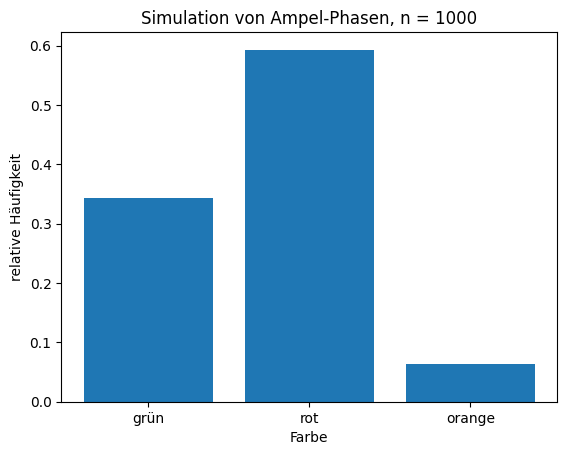

In [21]:
frequencies = np.array([counter[xi] for xi in x]) / len(lights)

plt.bar(x, frequencies)
plt.xlabel("Farbe")
plt.ylabel("relative Häufigkeit")
plt.title(f"Simulation von Ampel-Phasen, n = {n}")
plt.show()

Alternative mit Pandas:

In [22]:
import pandas as pd

pd_freq = pd.Series(lights).value_counts(normalize=True)
pd_freq

rot       0.593
grün      0.343
orange    0.064
Name: proportion, dtype: float64

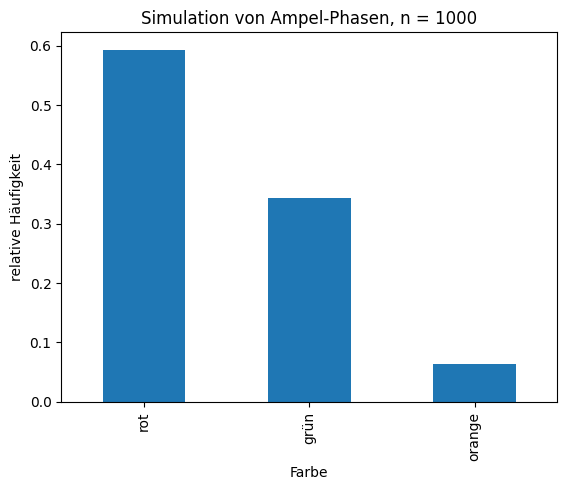

In [23]:
pd_freq.plot(kind="bar")
plt.xlabel("Farbe")
plt.ylabel("relative Häufigkeit")
plt.title(f"Simulation von Ampel-Phasen, n = {n}")
plt.show()

#### c) Direkte Variante mit [`rng.choice`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.choice.html)

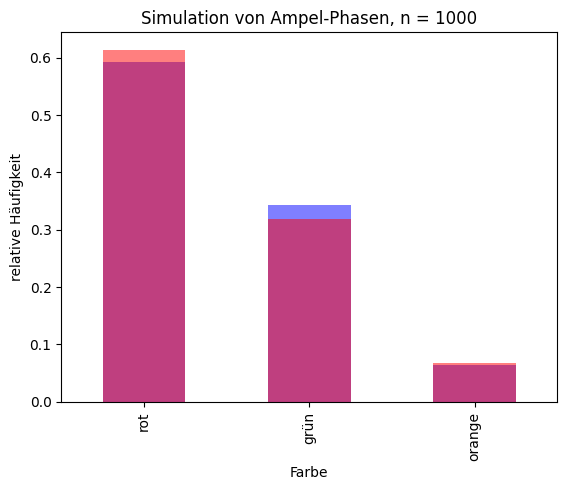

In [24]:
lights2 = rng.choice(x, size=n, p=p)
pd_freq2 = pd.Series(lights2).value_counts(normalize=True)

pd_freq.plot(kind="bar", color="b", alpha=0.5)
pd_freq2.plot(kind="bar", color="r", alpha=0.5)

plt.xlabel("Farbe")
plt.ylabel("relative Häufigkeit")
plt.title(f"Simulation von Ampel-Phasen, n = {n}")
plt.show()

#### d) Alternative: Verwerfungsmethode (Rejection Sampling) (optional)

Erklärung:

- ["Zufallszahlen generieren: Verwerfungsmethode 01: Die Idee" - LernenInVerschiedenenFormen](https://www.youtube.com/watch?v=il9W8vdESX0)
- ["Zufallszahlen generieren: Verwerfungsmethode 02: Algorithmus" - LernenInVerschiedenenFormen](https://www.youtube.com/watch?v=SaHA_NhELIo)

Übung: Implementiere die Verwerfungsmethode für die kontinuierliche [Dreiecksverteilung](https://de.wikipedia.org/wiki/Dreiecksverteilung) im Intervall $[0,1]$ mit der Wahrscheinlichkeitsdichte ($a=0$, $b=1$):

$$
    f_c(x) = \begin{cases}
        \dfrac{2x}{c} & \text{wenn } 0 \leq x < c \\[2ex]
        \dfrac{2(1-x)}{1-c} & \text{wenn } c \leq x \leq 1 \\[2ex]
        0 & \text{sonst}
    \end{cases}
$$